## Step 1: Synthesizing the Raw Data

In [2]:
import pandas as pd
import numpy as np

# Creating a messy dataset
raw_data = {
    'Transaction_ID': [1001, 1002, 1003, 1004, 1005, 1005, 1006, 1007, 1008, 1009],
    'Date': ['2026-01-01', '2026-01-02', '01-03-2026', '2026-01-04', '2026-01-05', '2026-01-05', '2026-01-06', '2026-01-07', '2026-01-08', '2026-01-09'],
    'Product_Category': ['Electronics', 'Clothing', 'Home', 'Electronics', 'Clothing', 'Clothing', np.nan, 'Home', 'Electronics', 'Home'],
    'Quantity': [1, 2, 1, 5, np.nan, np.nan, 2, 1, 3, 1],
    'Price_Per_Unit': [500, 25, 45, 120, 30, 30, 15, 99999, 150, 60] # Note the 99999 outlier
}

df_raw = pd.DataFrame(raw_data)
print("--- RAW DATASET ---")
print(df_raw)

--- RAW DATASET ---
   Transaction_ID        Date Product_Category  Quantity  Price_Per_Unit
0            1001  2026-01-01      Electronics       1.0             500
1            1002  2026-01-02         Clothing       2.0              25
2            1003  01-03-2026             Home       1.0              45
3            1004  2026-01-04      Electronics       5.0             120
4            1005  2026-01-05         Clothing       NaN              30
5            1005  2026-01-05         Clothing       NaN              30
6            1006  2026-01-06              NaN       2.0              15
7            1007  2026-01-07             Home       1.0           99999
8            1008  2026-01-08      Electronics       3.0             150
9            1009  2026-01-09             Home       1.0              60


## Step 2: Data Preprocessing & Cleaning

In [3]:
# Copy the dataset to keep the original safe
df_cleaned = df_raw.copy()

# 1. Handle Duplicates
# Transaction_ID 1005 is duplicated. Let's drop it.
df_cleaned.drop_duplicates(inplace=True)

# 2. Standardize Date Formats
# Row 2 has a 'MM-DD-YYYY' format while others are 'YYYY-MM-DD'
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'], errors='coerce')

# 3. Handle Missing Values (Imputation)
# Fill missing Product_Category with 'Unknown'
df_cleaned['Product_Category'] = df_cleaned['Product_Category'].fillna('Unknown')
# Fill missing Quantity with the median quantity (which is 1.5 -> rounded to 2)
median_quantity = df_cleaned['Quantity'].median()
df_cleaned['Quantity'] = df_cleaned['Quantity'].fillna(median_quantity)

# 4. Handle Outliers
# Price 99999 for a 'Home' item is clearly a data entry typo. 
# Let's replace anything over $1000 with the median price of valid entries.
median_price = df_cleaned[df_cleaned['Price_Per_Unit'] < 1000]['Price_Per_Unit'].median()
df_cleaned.loc[df_cleaned['Price_Per_Unit'] > 1000, 'Price_Per_Unit'] = median_price

# 5. Feature Engineering
# Create a Total_Sales column
df_cleaned['Total_Sales'] = df_cleaned['Quantity'] * df_cleaned['Price_Per_Unit']

print("\n--- CLEANED DATASET ---")
print(df_cleaned)


--- CLEANED DATASET ---
   Transaction_ID       Date Product_Category  Quantity  Price_Per_Unit  \
0            1001 2026-01-01      Electronics       1.0           500.0   
1            1002 2026-01-02         Clothing       2.0            25.0   
2            1003        NaT             Home       1.0            45.0   
3            1004 2026-01-04      Electronics       5.0           120.0   
4            1005 2026-01-05         Clothing       1.5            30.0   
6            1006 2026-01-06          Unknown       2.0            15.0   
7            1007 2026-01-07             Home       1.0            52.5   
8            1008 2026-01-08      Electronics       3.0           150.0   
9            1009 2026-01-09             Home       1.0            60.0   

   Total_Sales  
0        500.0  
1         50.0  
2         45.0  
3        600.0  
4         45.0  
6         30.0  
7         52.5  
8        450.0  
9         60.0  


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17952\4125366657.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '52.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_cleaned.loc[df_cleaned['Price_Per_Unit'] > 1000, 'Price_Per_Unit'] = median_price


## Step 3: Data Visualization & Insights

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17952\3912541869.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product_Category', y='Total_Sales', data=sales_by_cat, ax=axes[0], palette='Blues_d')


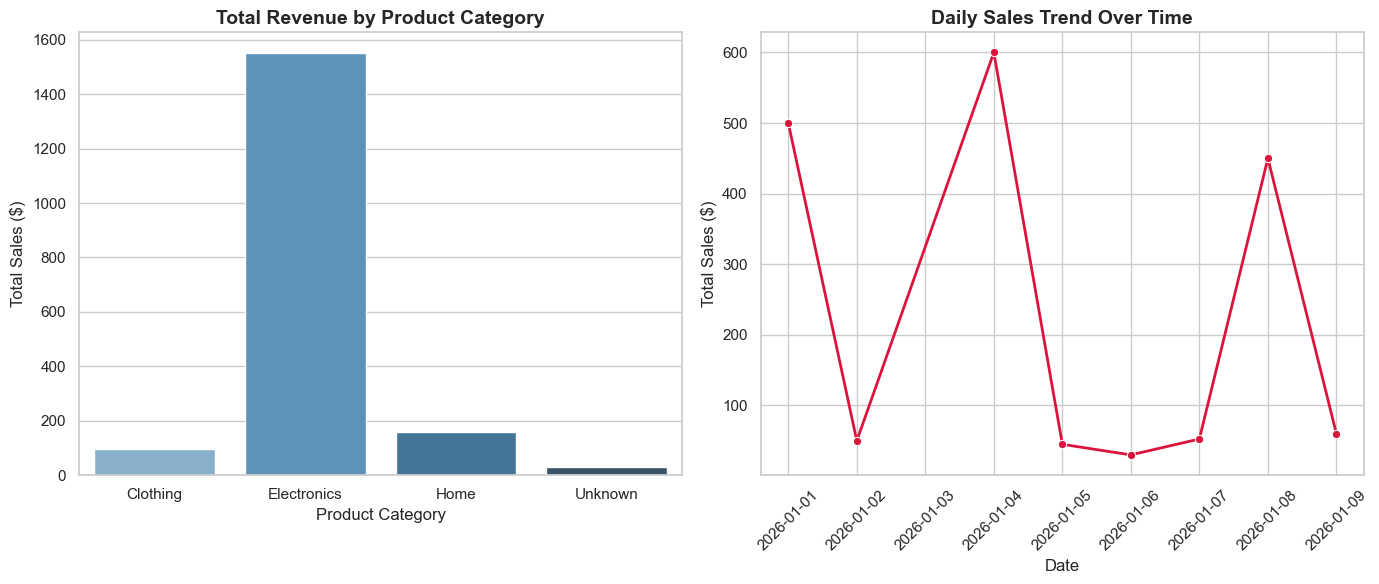

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Total Sales by Product Category (Bar Chart)
sales_by_cat = df_cleaned.groupby('Product_Category')['Total_Sales'].sum().reset_index()
sns.barplot(x='Product_Category', y='Total_Sales', data=sales_by_cat, ax=axes[0], palette='Blues_d')
axes[0].set_title('Total Revenue by Product Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Total Sales ($)')

# Chart 2: Daily Sales Trend (Line Chart)
sales_by_date = df_cleaned.groupby('Date')['Total_Sales'].sum().reset_index()
sns.lineplot(x='Date', y='Total_Sales', data=sales_by_date, ax=axes[1], marker='o', color='crimson', linewidth=2)
axes[1].set_title('Daily Sales Trend Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Sales ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()